# 05 — Seleção da melhor técnica e comparação entre modelos usando BERTScore F1

Este notebook usa **somente BERTScore F1** para comparar `zero-shot`, `one-shot` e `few-shot`, primeiro dentro de cada modelo e depois entre modelos.

## Entrada

Coloque os CSVs de BERTScore em:

```text
bertscore/
```

O notebook identifica **modelo** e **técnica** pelo conteúdo do CSV (`modelo/model` e `tecnica/technique`), e não pelo nome do arquivo.

Desenho esperado:

- 5 modelos;
- 3 técnicas;
- 259 casos por condição;
- 10 execuções por caso;
- 15 arquivos BERTScore;
- 38.850 escores brutos.

## Pipeline

1. Validar arquivos e execuções.
2. Agregar as 10 execuções por `caso × modelo × técnica`.
3. Calcular BERTScore médio, mediana, SD e CV.
4. Diagnosticar normalidade das diferenças pareadas.
5. Comparar técnicas por modelo:
   - Friedman;
   - Wilcoxon pareado;
   - Holm;
   - rank-biserial;
   - IC95% bootstrap da diferença média.
6. Encontrar a melhor técnica de cada modelo.
7. Encontrar a melhor técnica global.
8. Ajustar modelo linear misto `BERTScore ~ Modelo * Técnica + (1|Caso)`.
9. Comparar modelos:
   - pela melhor configuração observada de cada um;
   - sob a mesma técnica global.
10. Gerar um **resumo completo em TXT**.

As 10 execuções são agregadas antes da inferência para evitar pseudorreplicação. A estabilidade continua sendo avaliada pelo CV das 10 execuções.

In [ ]:
from pathlib import Path
from itertools import combinations
import re, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

try:
    import statsmodels.formula.api as smf
    STATSMODELS_DISPONIVEL = True
except Exception:
    STATSMODELS_DISPONIVEL = False

## 1. Configurações

In [ ]:
PASTA_BERTSCORE = Path("bertscore")
PASTA_SAIDA = Path("resultados_bertscore")
PASTA_SAIDA.mkdir(parents=True, exist_ok=True)

QUANTIDADE_MODELOS_ESPERADA = 5
TECNICAS_ESPERADAS = ["zero-shot", "one-shot", "few-shot"]
TOTAL_CASOS_ESPERADO = 259
EXECUCOES_ESPERADAS = set(range(1, 11))
TOTAL_EXECUCOES_ESPERADO = 10
LINHAS_ESPERADAS_POR_ARQUIVO = TOTAL_CASOS_ESPERADO * TOTAL_EXECUCOES_ESPERADO
ARQUIVOS_BERTSCORE_ESPERADOS = QUANTIDADE_MODELOS_ESPERADA * len(TECNICAS_ESPERADAS)

ALPHA = 0.05
N_BOOTSTRAP = 5000
SEED_BOOTSTRAP = 20260828
VALIDACAO_ESTRITA = True

## 2. Funções auxiliares

In [ ]:
def normalizar_nome_coluna(nome):
    nome = str(nome).strip().lower()
    for a,b in {"á":"a","à":"a","ã":"a","â":"a","é":"e","ê":"e","í":"i","ó":"o","ô":"o","õ":"o","ú":"u","ç":"c"}.items():
        nome = nome.replace(a,b)
    return re.sub(r"[^a-z0-9]+","_",nome).strip("_")

def normalizar_tecnica(v):
    v = re.sub(r"\s+","-",str(v).strip().lower().replace("_","-"))
    base = v.replace("-","")
    mapa = {"zeroshot":"zero-shot","oneshot":"one-shot","fewshot":"few-shot"}
    return mapa.get(base, v)

def ler_csv_robusto(caminho):
    ultimo = None
    for enc in ["utf-8-sig","utf-8","latin1"]:
        try:
            df = pd.read_csv(caminho, encoding=enc)
            if len(df.columns)==1:
                df2 = pd.read_csv(caminho, sep=";", encoding=enc)
                if len(df2.columns)>1: df=df2
            return df
        except Exception as e:
            ultimo=e
    raise RuntimeError(f"Falha lendo {caminho}: {ultimo}")

def padronizar_colunas(df):
    df=df.copy()
    df.columns=[normalizar_nome_coluna(c) for c in df.columns]
    df=df.rename(columns={"modelo":"model","tecnica":"technique","execucao":"execution"})
    return df

def unico(df,col,arquivo):
    if col not in df.columns:
        raise ValueError(f"{arquivo}: coluna ausente: {col}")
    vals=df[col].dropna().astype(str).str.strip().unique()
    if len(vals)!=1:
        raise ValueError(f"{arquivo}: esperava 1 valor em {col}, encontrei {vals[:10]}")
    return vals[0]

def holm_bonferroni(p_values):
    p=np.asarray(p_values,dtype=float)
    out=np.full(len(p),np.nan)
    ids=np.where(np.isfinite(p))[0]
    if not len(ids): return out
    pv=p[ids]; ordem=np.argsort(pv); ordenados=pv[ordem]; m=len(ordenados)
    adj=np.empty(m); prev=0.0
    for i,val in enumerate(ordenados):
        cur=min(1.0,(m-i)*val)
        prev=max(prev,cur); adj[i]=prev
    rev=np.empty(m); rev[ordem]=adj; out[ids]=rev
    return out

def shapiro_seguro(vals):
    s=pd.Series(vals)
    s=pd.to_numeric(s,errors="coerce").replace([np.inf,-np.inf],np.nan).dropna()
    if len(s)<3 or s.nunique()<2:
        return {"n":len(s),"W":np.nan,"p":np.nan,"rejeita":None}
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        r=stats.shapiro(s.to_numpy(float))
    return {"n":len(s),"W":float(r.statistic),"p":float(r.pvalue),"rejeita":bool(r.pvalue<ALPHA)}

def rank_biserial_pareado(a,b):
    d=np.asarray(a,float)-np.asarray(b,float)
    d=d[d!=0]
    if not len(d): return 0.0
    ranks=stats.rankdata(np.abs(d))
    wp=float(ranks[d>0].sum()); wn=float(ranks[d<0].sum())
    return (wp-wn)/(wp+wn) if (wp+wn) else 0.0

def bootstrap_media_diff(a,b,n=N_BOOTSTRAP,seed=SEED_BOOTSTRAP):
    d=np.asarray(a,float)-np.asarray(b,float)
    rng=np.random.default_rng(seed)
    means=np.empty(n)
    for i in range(n):
        idx=rng.integers(0,len(d),len(d))
        means[i]=d[idx].mean()
    lo,hi=np.percentile(means,[2.5,97.5])
    return float(d.mean()),float(lo),float(hi)

## 3. Ler, identificar e validar os CSVs

In [ ]:
arquivos=sorted(PASTA_BERTSCORE.rglob("*.csv"))
if not arquivos:
    raise RuntimeError(f"Nenhum CSV encontrado em {PASTA_BERTSCORE.resolve()}")

inventario=[]; dados={}; ignorados=[]

for path in arquivos:
    df=padronizar_colunas(ler_csv_robusto(path))
    if "bertscore_f1" not in df.columns:
        ignorados.append(path.name)
        continue

    model=unico(df,"model",path.name)
    tech=normalizar_tecnica(unico(df,"technique",path.name))

    for c in ["case_id","execution","generation_id"]:
        if c not in df.columns:
            raise ValueError(f"{path.name}: coluna ausente: {c}")

    df["technique"]=tech
    df["execution"]=pd.to_numeric(df["execution"],errors="raise").astype(int)
    df["bertscore_f1"]=pd.to_numeric(df["bertscore_f1"],errors="coerce")

    chave=(model,tech)
    if chave in dados:
        raise RuntimeError(f"Duplicidade modelo×técnica: {chave}")

    casos_ruins=[]
    for cid,g in df.groupby("case_id"):
        if set(g["execution"].unique()) != EXECUCOES_ESPERADAS:
            casos_ruins.append(cid)

    inventario.append({
        "modelo":model,"tecnica":tech,"arquivo":path.name,
        "linhas":len(df),"casos_unicos":df["case_id"].nunique(),
        "generation_ids_unicos":df["generation_id"].nunique(),
        "generation_ids_duplicados":int(df["generation_id"].duplicated().sum()),
        "casos_execucoes_invalidas":len(casos_ruins),
        "bertscore_ausentes":int(df["bertscore_f1"].isna().sum())
    })
    dados[chave]={"df":df,"arquivo":path.name}

df_inventario=pd.DataFrame(inventario).sort_values(["modelo","tecnica"]).reset_index(drop=True)
display(df_inventario)

modelos=sorted(df_inventario["modelo"].unique())
problemas=[]
if len(modelos)!=QUANTIDADE_MODELOS_ESPERADA:
    problemas.append(f"Esperados 5 modelos; encontrados {len(modelos)}")
if set(df_inventario["tecnica"].unique())!=set(TECNICAS_ESPERADAS):
    problemas.append("Conjunto de técnicas diferente do esperado")
if len(df_inventario)!=ARQUIVOS_BERTSCORE_ESPERADOS:
    problemas.append(f"Esperados 15 arquivos BERTScore; encontrados {len(df_inventario)}")

for m in modelos:
    for t in TECNICAS_ESPERADAS:
        if (m,t) not in dados:
            problemas.append(f"Falta combinação: {m} | {t}")

for _,r in df_inventario.iterrows():
    ident=f"{r['modelo']} | {r['tecnica']}"
    if r["linhas"]!=LINHAS_ESPERADAS_POR_ARQUIVO: problemas.append(f"{ident}: linhas={r['linhas']}")
    if r["casos_unicos"]!=TOTAL_CASOS_ESPERADO: problemas.append(f"{ident}: casos={r['casos_unicos']}")
    if r["generation_ids_unicos"]!=LINHAS_ESPERADAS_POR_ARQUIVO: problemas.append(f"{ident}: IDs únicos={r['generation_ids_unicos']}")
    if r["generation_ids_duplicados"]!=0: problemas.append(f"{ident}: IDs duplicados")
    if r["casos_execucoes_invalidas"]!=0: problemas.append(f"{ident}: casos sem execuções exatas 1..10")
    if r["bertscore_ausentes"]!=0: problemas.append(f"{ident}: BERTScore ausente")

# mesmos cases
refs=None
for chave,conteudo in dados.items():
    s=set(conteudo["df"]["case_id"])
    if refs is None: refs=s
    elif s!=refs: problemas.append(f"{chave}: conjunto de case_id diverge")

if problemas:
    print("PROBLEMAS:")
    for p in problemas: print(" -",p)
    if VALIDACAO_ESTRITA: raise RuntimeError("Validação falhou.")
else:
    print(f"OK: {len(modelos)} modelos × 3 técnicas = {len(df_inventario)} arquivos; 259 casos × 10 execuções.")
if ignorados:
    print("Ignorados por não conter bertscore_f1:", ignorados)

,modelo,tecnica,arquivo,linhas,casos_unicos,generation_ids_unicos,generation_ids_duplicados,casos_execucoes_invalidas,bertscore_ausentes
0,Qwen/Qwen3-8B,few-shot,metricas_bertscore_qwen-qwen3-8b_few-shot.csv,2590,259,2590,0,0,0
1,Qwen/Qwen3-8B,one-shot,metricas_bertscore_qwen-qwen3-8b_one-shot.csv,2590,259,2590,0,0,0
2,Qwen/Qwen3-8B,zero-shot,metricas_bertscore_qwen-qwen3-8b_zero-shot.csv,2590,259,2590,0,0,0
3,google/gemma-4-E4B-it,few-shot,metricas_bertscore_google-gemma-4-e4b-it_few-s...,2590,259,2590,0,0,0
4,google/gemma-4-E4B-it,one-shot,metricas_bertscore_google-gemma-4-e4b-it_one-s...,2590,259,2590,0,0,0
5,google/gemma-4-E4B-it,zero-shot,metricas_bertscore_google-gemma-4-e4b-it_zero-...,2590,259,2590,0,0,0
6,ibm-granite/granite-4.1-8b,few-shot,metricas_bertscore_ibm-granite-granite-4.1-8b_...,2590,259,2590,0,0,0
7,ibm-granite/granite-4.1-8b,one-shot,metricas_bertscore_ibm-granite-granite-4.1-8b_...,2590,259,2590,0,0,0
8,ibm-granite/granite-4.1-8b,zero-shot,metricas_bertscore_ibm-granite-granite-4.1-8b_...,2590,259,2590,0,0,0
9,meta-llama/Meta-Llama-3-8B-Instruct,few-shot,metricas_bertscore_meta-llama-meta-llama-3-8b-...,2590,259,2590,0,0,0


OK: 5 modelos × 3 técnicas = 15 arquivos; 259 casos × 10 execuções.


## 4. Consolidar e agregar as 10 execuções

In [ ]:
brutos=[]
for (m,t),obj in dados.items():
    x=obj["df"][["case_id","execution","generation_id","bertscore_f1"]].copy()
    x["model"]=m; x["technique"]=t
    brutos.append(x)

df_bruto=pd.concat(brutos,ignore_index=True)

df_agregado=(
    df_bruto.groupby(["case_id","model","technique"],as_index=False)
    .agg(
        bertscore_mean=("bertscore_f1","mean"),
        bertscore_median=("bertscore_f1","median"),
        bertscore_sd=("bertscore_f1","std"),
        bertscore_min=("bertscore_f1","min"),
        bertscore_max=("bertscore_f1","max"),
        execucoes=("execution","nunique")
    )
)
df_agregado["bertscore_cv_percent"]=np.where(
    df_agregado["bertscore_mean"]!=0,
    df_agregado["bertscore_sd"]/np.abs(df_agregado["bertscore_mean"])*100,
    np.nan
)

esperado=TOTAL_CASOS_ESPERADO*len(modelos)*len(TECNICAS_ESPERADAS)
assert len(df_agregado)==esperado
assert (df_agregado["execucoes"]==10).all()

mn=float(df_bruto["bertscore_f1"].min()); mx=float(df_bruto["bertscore_f1"].max())
ESCALA_BERT="0–1 (aproximada)" if mx<=1.5 else ("0–100 (aproximada)" if mx<=100.5 else "não reconhecida")
print(f"Registros brutos: {len(df_bruto):,}")
print(f"Agregados: {len(df_agregado):,}")
print(f"Escala detectada: {ESCALA_BERT}; min={mn:.6f}; max={mx:.6f}")
display(df_agregado.head())

Registros brutos: 38,850
Agregados: 3,885
Escala detectada: 0–100 (aproximada); min=-33.128368; max=88.542000


,case_id,model,technique,bertscore_mean,bertscore_median,bertscore_sd,bertscore_min,bertscore_max,execucoes,bertscore_cv_percent
0,TC_1,Qwen/Qwen3-8B,few-shot,45.109708,45.729610,1.476005,42.886688,46.454571,10,3.272035
1,TC_1,Qwen/Qwen3-8B,one-shot,43.116087,43.972742,4.371905,32.130119,48.157017,10,10.139847
2,TC_1,Qwen/Qwen3-8B,zero-shot,50.821972,50.350870,5.305522,45.085239,56.559788,10,10.439426
3,TC_1,google/gemma-4-E4B-it,few-shot,26.695311,35.393076,19.806321,-14.877540,38.933266,10,74.194007
4,TC_1,google/gemma-4-E4B-it,one-shot,37.761788,37.804325,1.049556,35.570896,39.029457,10,2.779413


## 5. Descritiva de qualidade e estabilidade

In [ ]:
df_descritiva=(
    df_agregado.groupby(["model","technique"],as_index=False)
    .agg(
        n_casos=("case_id","nunique"),
        media_bertscore=("bertscore_mean","mean"),
        mediana_bertscore=("bertscore_mean","median"),
        sd_entre_casos=("bertscore_mean","std"),
        media_cv_execucoes=("bertscore_cv_percent","mean"),
        mediana_cv_execucoes=("bertscore_cv_percent","median"),
        media_sd_execucoes=("bertscore_sd","mean")
    )
)
df_descritiva["sem"]=df_descritiva["sd_entre_casos"]/np.sqrt(df_descritiva["n_casos"])
df_descritiva["ic95_media_inf"]=df_descritiva["media_bertscore"]-1.96*df_descritiva["sem"]
df_descritiva["ic95_media_sup"]=df_descritiva["media_bertscore"]+1.96*df_descritiva["sem"]
display(df_descritiva.sort_values(["model","media_bertscore"],ascending=[True,False]))

,model,technique,n_casos,media_bertscore,mediana_bertscore,sd_entre_casos,media_cv_execucoes,mediana_cv_execucoes,media_sd_execucoes,sem,ic95_media_inf,ic95_media_sup
2,Qwen/Qwen3-8B,zero-shot,259,54.211268,54.627691,9.350837,5.328317,3.981359,2.684105,0.581033,53.072444,55.350092
0,Qwen/Qwen3-8B,few-shot,259,48.083370,48.070685,8.341176,3.710034,2.954027,1.705592,0.518295,47.067511,49.099229
1,Qwen/Qwen3-8B,one-shot,259,48.057866,48.493813,8.746363,3.910498,2.798256,1.793160,0.543473,46.992660,49.123072
5,google/gemma-4-E4B-it,zero-shot,259,42.383804,42.442629,7.656204,23.751750,16.532032,9.427750,0.475733,41.451367,43.316241
4,google/gemma-4-E4B-it,one-shot,259,39.495646,40.028135,7.757582,24.412322,17.243693,8.817259,0.482033,38.550862,40.440430
3,google/gemma-4-E4B-it,few-shot,259,37.958213,37.933493,7.863305,30.447124,27.081324,10.327350,0.488602,37.000553,38.915872
8,ibm-granite/granite-4.1-8b,zero-shot,259,48.735927,48.138307,8.447133,7.682137,6.662821,3.627562,0.524879,47.707163,49.764690
7,ibm-granite/granite-4.1-8b,one-shot,259,47.307749,47.759996,7.088533,5.890388,5.013830,2.738991,0.440460,46.444447,48.171050
6,ibm-granite/granite-4.1-8b,few-shot,259,47.083290,47.308065,7.227046,5.190905,4.389136,2.382222,0.449067,46.203120,47.963461
11,meta-llama/Meta-Llama-3-8B-Instruct,zero-shot,259,53.983162,54.227319,7.834719,9.166332,8.158699,4.861768,0.486826,53.028983,54.937340


## 6. Diagnóstico de normalidade das diferenças pareadas

In [ ]:
norm=[]
for m in modelos:
    p=df_agregado[df_agregado["model"]==m].pivot(index="case_id",columns="technique",values="bertscore_mean")[TECNICAS_ESPERADAS].dropna()
    for a,b in combinations(TECNICAS_ESPERADAS,2):
        sh=shapiro_seguro(p[a]-p[b])
        norm.append({"modelo":m,"tecnica_a":a,"tecnica_b":b,"n":sh["n"],"W":sh["W"],"p":sh["p"],"rejeita_normalidade":sh["rejeita"]})
df_normalidade_diferencas=pd.DataFrame(norm)
display(df_normalidade_diferencas)

,modelo,tecnica_a,tecnica_b,n,W,p,rejeita_normalidade
0,Qwen/Qwen3-8B,zero-shot,one-shot,259,0.965635,7.216061e-06,True
1,Qwen/Qwen3-8B,zero-shot,few-shot,259,0.944908,2.706668e-08,True
2,Qwen/Qwen3-8B,one-shot,few-shot,259,0.969321,2.322996e-05,True
3,google/gemma-4-E4B-it,zero-shot,one-shot,259,0.993941,3.849807e-01,False
4,google/gemma-4-E4B-it,zero-shot,few-shot,259,0.994208,4.257802e-01,False
5,google/gemma-4-E4B-it,one-shot,few-shot,259,0.993911,3.806298e-01,False
6,ibm-granite/granite-4.1-8b,zero-shot,one-shot,259,0.988291,3.379249e-02,True
7,ibm-granite/granite-4.1-8b,zero-shot,few-shot,259,0.984359,6.164689e-03,True
8,ibm-granite/granite-4.1-8b,one-shot,few-shot,259,0.975649,2.044369e-04,True
9,meta-llama/Meta-Llama-3-8B-Instruct,zero-shot,one-shot,259,0.973997,1.133192e-04,True


## 7. Comparação das técnicas dentro de cada modelo

O teste principal é o **Friedman**, pois os mesmos 259 casos aparecem nas três técnicas.  
Quando há diferença global, os pares são comparados com **Wilcoxon pareado + Holm**.

In [ ]:
fried=[]; post=[]
for m in modelos:
    p=df_agregado[df_agregado["model"]==m].pivot(index="case_id",columns="technique",values="bertscore_mean")[TECNICAS_ESPERADAS].dropna()
    fr=stats.friedmanchisquare(*(p[t] for t in TECNICAS_ESPERADAS))
    n=len(p); k=3
    fried.append({"modelo":m,"n":n,"friedman_chi2":float(fr.statistic),"df":2,"p_value":float(fr.pvalue),"kendall_W":float(fr.statistic/(n*(k-1))),"significativo":bool(fr.pvalue<ALPHA)})

    tmp=[]
    for j,(a,b) in enumerate(combinations(TECNICAS_ESPERADAS,2)):
        va=p[a].to_numpy(float); vb=p[b].to_numpy(float)
        if np.allclose(va-vb,0):
            w,pv=0.0,1.0
        else:
            rr=stats.wilcoxon(va,vb,alternative="two-sided",zero_method="wilcox")
            w,pv=float(rr.statistic),float(rr.pvalue)
        d,lo,hi=bootstrap_media_diff(va,vb,seed=SEED_BOOTSTRAP+j)
        tmp.append({"modelo":m,"tecnica_a":a,"tecnica_b":b,"n":len(va),"media_a":va.mean(),"media_b":vb.mean(),
                    "diferenca_media_a_menos_b":d,"ic95_diff_inf":lo,"ic95_diff_sup":hi,
                    "wilcoxon_W":w,"p_original":pv,"rank_biserial":rank_biserial_pareado(va,vb)})
    adj=holm_bonferroni([x["p_original"] for x in tmp])
    for x,ph in zip(tmp,adj):
        x["p_holm"]=float(ph); x["significativo_holm"]=bool(ph<ALPHA)
        if not x["significativo_holm"]: x["interpretacao"]="diferença não significativa"
        elif x["diferenca_media_a_menos_b"]>0: x["interpretacao"]=f"{x['tecnica_a']} > {x['tecnica_b']}"
        else: x["interpretacao"]=f"{x['tecnica_b']} > {x['tecnica_a']}"
        post.append(x)

df_friedman_modelo=pd.DataFrame(fried)
df_posthoc_tecnicas=pd.DataFrame(post)
display(df_friedman_modelo)
display(df_posthoc_tecnicas)

,modelo,n,friedman_chi2,df,p_value,kendall_W,significativo
0,Qwen/Qwen3-8B,259,171.503382,2,5.734742e-38,0.331088,True
1,google/gemma-4-E4B-it,259,82.108108,2,1.480645e-18,0.158510,True
2,ibm-granite/granite-4.1-8b,259,40.679537,2,1.467408e-09,0.078532,True
3,meta-llama/Meta-Llama-3-8B-Instruct,259,112.918919,2,3.019731e-25,0.217990,True
4,mistralai/Mistral-7B-Instruct-v0.3,259,251.190338,2,2.849122e-55,0.484923,True


,modelo,tecnica_a,tecnica_b,n,media_a,media_b,diferenca_media_a_menos_b,ic95_diff_inf,ic95_diff_sup,wilcoxon_W,p_original,rank_biserial,p_holm,significativo_holm,interpretacao
0,Qwen/Qwen3-8B,zero-shot,one-shot,259,54.211268,48.057866,6.153402,5.259174,7.038521,3254.0,2.206581e-29,0.806712,6.619743e-29,True,zero-shot > one-shot
1,Qwen/Qwen3-8B,zero-shot,few-shot,259,54.211268,48.083370,6.127898,5.208729,7.071898,3433.0,1.173866e-28,0.796080,2.347732e-28,True,zero-shot > few-shot
2,Qwen/Qwen3-8B,one-shot,few-shot,259,48.057866,48.083370,-0.025504,-0.570170,0.520105,16373.0,7.816760e-01,0.019904,7.816760e-01,False,diferença não significativa
3,google/gemma-4-E4B-it,zero-shot,one-shot,259,42.383804,39.495646,2.888158,2.107476,3.680146,8733.0,1.894348e-11,0.481259,3.788697e-11,True,zero-shot > one-shot
4,google/gemma-4-E4B-it,zero-shot,few-shot,259,42.383804,37.958213,4.425591,3.565098,5.287328,6015.0,3.066776e-19,0.642709,9.200327e-19,True,zero-shot > few-shot
5,google/gemma-4-E4B-it,one-shot,few-shot,259,39.495646,37.958213,1.537433,0.795913,2.306452,12417.0,2.511388e-04,0.262429,2.511388e-04,True,one-shot > few-shot
6,ibm-granite/granite-4.1-8b,zero-shot,one-shot,259,48.735927,47.307749,1.428178,0.866378,1.997439,10563.0,2.020264e-07,0.372557,4.040527e-07,True,zero-shot > one-shot
7,ibm-granite/granite-4.1-8b,zero-shot,few-shot,259,48.735927,47.083290,1.652636,1.071463,2.239574,9993.0,1.429565e-08,0.406415,4.288695e-08,True,zero-shot > few-shot
8,ibm-granite/granite-4.1-8b,one-shot,few-shot,259,47.307749,47.083290,0.224458,-0.093385,0.549455,14890.0,1.070104e-01,0.115533,1.070104e-01,False,diferença não significativa
9,meta-llama/Meta-Llama-3-8B-Instruct,zero-shot,one-shot,259,53.983162,53.096080,0.887082,0.283070,1.506674,13826.0,1.264943e-02,0.178735,1.264943e-02,True,zero-shot > one-shot


## 8. Selecionar a melhor técnica de cada modelo

In [ ]:
melhores=[]
for m in modelos:
    d=df_descritiva[df_descritiva["model"]==m].sort_values("media_bertscore",ascending=False).reset_index(drop=True)
    top=d.iloc[0]; tech=top["technique"]
    pares=df_posthoc_tecnicas[(df_posthoc_tecnicas["modelo"]==m)&((df_posthoc_tecnicas["tecnica_a"]==tech)|(df_posthoc_tecnicas["tecnica_b"]==tech))]
    superior=True; detalhes=[]
    for _,r in pares.iterrows():
        if r["tecnica_a"]==tech:
            outra=r["tecnica_b"]; delta=r["diferenca_media_a_menos_b"]
        else:
            outra=r["tecnica_a"]; delta=-r["diferenca_media_a_menos_b"]
        ok=bool(r["significativo_holm"] and delta>0)
        superior &= ok
        detalhes.append(f"{tech} vs {outra}: Δ={delta:.6f}; p-Holm={r['p_holm']:.6g}; {'superior' if ok else 'não demonstrou superioridade'}")
    estavel=d.sort_values("media_cv_execucoes").iloc[0]["technique"]
    melhores.append({
        "modelo":m,"melhor_tecnica_observada":tech,
        "media_bertscore":float(top["media_bertscore"]),
        "mediana_bertscore":float(top["mediana_bertscore"]),
        "media_cv_percent":float(top["media_cv_execucoes"]),
        "tecnica_mais_estavel":estavel,
        "superior_a_todas_holm":bool(superior),
        "status":"vencedora estatisticamente suportada" if superior else "maior média observada; superioridade sobre todas não demonstrada",
        "detalhes_posthoc":" | ".join(detalhes)
    })
df_melhores_tecnicas=pd.DataFrame(melhores)
display(df_melhores_tecnicas)

,modelo,melhor_tecnica_observada,media_bertscore,mediana_bertscore,media_cv_percent,tecnica_mais_estavel,superior_a_todas_holm,status,detalhes_posthoc
0,Qwen/Qwen3-8B,zero-shot,54.211268,54.627691,5.328317,few-shot,True,vencedora estatisticamente suportada,zero-shot vs one-shot: Δ=6.153402; p-Holm=6.61...
1,google/gemma-4-E4B-it,zero-shot,42.383804,42.442629,23.751750,zero-shot,True,vencedora estatisticamente suportada,zero-shot vs one-shot: Δ=2.888158; p-Holm=3.78...
2,ibm-granite/granite-4.1-8b,zero-shot,48.735927,48.138307,7.682137,few-shot,True,vencedora estatisticamente suportada,zero-shot vs one-shot: Δ=1.428178; p-Holm=4.04...
3,meta-llama/Meta-Llama-3-8B-Instruct,zero-shot,53.983162,54.227319,9.166332,one-shot,True,vencedora estatisticamente suportada,zero-shot vs one-shot: Δ=0.887082; p-Holm=0.01...
4,mistralai/Mistral-7B-Instruct-v0.3,zero-shot,50.205749,50.035751,11.163931,few-shot,True,vencedora estatisticamente suportada,zero-shot vs one-shot: Δ=7.734800; p-Holm=6.65...


## 9. Melhor técnica global

In [ ]:
# média dos 5 modelos dentro de cada caso para não multiplicar artificialmente o n
df_tecnica_global_caso=(
    df_agregado.groupby(["case_id","technique"],as_index=False)
    .agg(bertscore_mean_modelos=("bertscore_mean","mean"))
)
pg=df_tecnica_global_caso.pivot(index="case_id",columns="technique",values="bertscore_mean_modelos")[TECNICAS_ESPERADAS].dropna()
frg=stats.friedmanchisquare(*(pg[t] for t in TECNICAS_ESPERADAS))
kendall_global=float(frg.statistic/(len(pg)*(len(TECNICAS_ESPERADAS)-1)))

postg=[]
for j,(a,b) in enumerate(combinations(TECNICAS_ESPERADAS,2)):
    va=pg[a].to_numpy(float); vb=pg[b].to_numpy(float)
    rr=stats.wilcoxon(va,vb,alternative="two-sided",zero_method="wilcox")
    d,lo,hi=bootstrap_media_diff(va,vb,seed=SEED_BOOTSTRAP+100+j)
    postg.append({"tecnica_a":a,"tecnica_b":b,"n":len(va),"media_a":va.mean(),"media_b":vb.mean(),"diferenca_media_a_menos_b":d,
                  "ic95_diff_inf":lo,"ic95_diff_sup":hi,"p_original":float(rr.pvalue),"rank_biserial":rank_biserial_pareado(va,vb)})
adj=holm_bonferroni([x["p_original"] for x in postg])
for x,ph in zip(postg,adj):
    x["p_holm"]=float(ph); x["significativo_holm"]=bool(ph<ALPHA)
    if not x["significativo_holm"]: x["interpretacao"]="diferença não significativa"
    elif x["diferenca_media_a_menos_b"]>0: x["interpretacao"]=f"{x['tecnica_a']} > {x['tecnica_b']}"
    else: x["interpretacao"]=f"{x['tecnica_b']} > {x['tecnica_a']}"
df_posthoc_global=pd.DataFrame(postg)

medias_tecnica_global=(
    df_tecnica_global_caso.groupby("technique",as_index=False)
    .agg(media_bertscore=("bertscore_mean_modelos","mean"),mediana_bertscore=("bertscore_mean_modelos","median"))
    .sort_values("media_bertscore",ascending=False).reset_index(drop=True)
)
TECNICA_GLOBAL_MELHOR=medias_tecnica_global.iloc[0]["technique"]
print(f"Friedman global: χ²={frg.statistic:.6f}, p={frg.pvalue:.6g}, Kendall W={kendall_global:.6f}")
display(medias_tecnica_global)
display(df_posthoc_global)
print("Técnica global de maior média observada:",TECNICA_GLOBAL_MELHOR)

Friedman global: χ²=295.320463, p=7.44691e-65, Kendall W=0.570117


,technique,media_bertscore,mediana_bertscore
0,zero-shot,49.903982,49.842036
1,one-shot,46.085658,46.300230
2,few-shot,45.104912,45.171815


,tecnica_a,tecnica_b,n,media_a,media_b,diferenca_media_a_menos_b,ic95_diff_inf,ic95_diff_sup,p_original,rank_biserial,p_holm,significativo_holm,interpretacao
0,zero-shot,one-shot,259,49.903982,46.085658,3.818324,3.407063,4.223176,3.149664e-37,0.913870,6.299328e-37,True,zero-shot > one-shot
1,zero-shot,few-shot,259,49.903982,45.104912,4.799070,4.341346,5.269731,2.354797e-39,0.940838,7.064390e-39,True,zero-shot > few-shot
2,one-shot,few-shot,259,46.085658,45.104912,0.980746,0.700438,1.269901,2.038128e-10,0.455777,2.038128e-10,True,one-shot > few-shot


Técnica global de maior média observada: zero-shot


## 10. Modelo linear misto — interação Modelo × Técnica

In [ ]:
LMM_OK=False; LMM_ERRO=None
df_lmm_testes=pd.DataFrame()

if STATSMODELS_DISPONIVEL:
    try:
        z=df_agregado[["case_id","model","technique","bertscore_mean"]].copy()
        full=smf.mixedlm("bertscore_mean ~ C(model) * C(technique)",z,groups=z["case_id"]).fit(reml=False,method="lbfgs",maxiter=500,disp=False)
        add=smf.mixedlm("bertscore_mean ~ C(model) + C(technique)",z,groups=z["case_id"]).fit(reml=False,method="lbfgs",maxiter=500,disp=False)
        only_m=smf.mixedlm("bertscore_mean ~ C(model)",z,groups=z["case_id"]).fit(reml=False,method="lbfgs",maxiter=500,disp=False)
        only_t=smf.mixedlm("bertscore_mean ~ C(technique)",z,groups=z["case_id"]).fit(reml=False,method="lbfgs",maxiter=500,disp=False)

        def lrt(maior,menor,nome):
            lr=2*(maior.llf-menor.llf)
            dfd=int(round(maior.df_modelwc-menor.df_modelwc))
            pv=float(stats.chi2.sf(lr,dfd))
            return {"efeito":nome,"LR":float(lr),"df":dfd,"p_value":pv,"significativo":bool(pv<ALPHA)}

        df_lmm_testes=pd.DataFrame([
            lrt(full,add,"modelo × técnica"),
            lrt(add,only_m,"técnica"),
            lrt(add,only_t,"modelo")
        ])
        LMM_OK=True
        display(df_lmm_testes)
        print(full.summary())
    except Exception as e:
        LMM_ERRO=str(e)
        print("LMM não convergiu/ajustou:",LMM_ERRO)
else:
    LMM_ERRO="statsmodels indisponível"
    print(LMM_ERRO)

LMM não convergiu/ajustou: Singular matrix


/usr/local/lib/python3.13/dist-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/usr/local/lib/python3.13/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.13/dist-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)


## 11. Comparar modelos usando a melhor técnica observada de cada um

In [ ]:
partes=[]
for _,r in df_melhores_tecnicas.iterrows():
    x=df_agregado[(df_agregado["model"]==r["modelo"])&(df_agregado["technique"]==r["melhor_tecnica_observada"])][["case_id","bertscore_mean"]].copy()
    x["model"]=r["modelo"]; x["selected_technique"]=r["melhor_tecnica_observada"]; partes.append(x)
df_best_config=pd.concat(partes,ignore_index=True)

pb=df_best_config.pivot(index="case_id",columns="model",values="bertscore_mean")[modelos].dropna()
frb=stats.friedmanchisquare(*(pb[m] for m in modelos))
kendall_best=float(frb.statistic/(len(pb)*(len(modelos)-1)))

postm=[]
for j,(a,b) in enumerate(combinations(modelos,2)):
    va=pb[a].to_numpy(float); vb=pb[b].to_numpy(float)
    rr=stats.wilcoxon(va,vb,alternative="two-sided",zero_method="wilcox")
    d,lo,hi=bootstrap_media_diff(va,vb,seed=SEED_BOOTSTRAP+1000+j)
    postm.append({"modelo_a":a,"modelo_b":b,"n":len(va),"media_a":va.mean(),"media_b":vb.mean(),"diferenca_media_a_menos_b":d,
                  "ic95_diff_inf":lo,"ic95_diff_sup":hi,"p_original":float(rr.pvalue),"rank_biserial":rank_biserial_pareado(va,vb)})
adj=holm_bonferroni([x["p_original"] for x in postm])
for x,ph in zip(postm,adj):
    x["p_holm"]=float(ph); x["significativo_holm"]=bool(ph<ALPHA)
    if not x["significativo_holm"]: x["interpretacao"]="diferença não significativa"
    elif x["diferenca_media_a_menos_b"]>0: x["interpretacao"]=f"{x['modelo_a']} > {x['modelo_b']}"
    else: x["interpretacao"]=f"{x['modelo_b']} > {x['modelo_a']}"
df_posthoc_modelos_best=pd.DataFrame(postm)

df_ranking_modelos_best=(
    df_best_config.groupby(["model","selected_technique"],as_index=False)
    .agg(media_bertscore=("bertscore_mean","mean"),mediana_bertscore=("bertscore_mean","median"),sd=("bertscore_mean","std"))
    .sort_values("media_bertscore",ascending=False).reset_index(drop=True)
)
df_ranking_modelos_best.insert(0,"posicao",np.arange(1,len(df_ranking_modelos_best)+1))

print(f"Friedman melhores configurações: χ²={frb.statistic:.6f}, p={frb.pvalue:.6g}, Kendall W={kendall_best:.6f}")
display(df_ranking_modelos_best)
display(df_posthoc_modelos_best)

Friedman melhores configurações: χ²=354.993050, p=1.4651e-75, Kendall W=0.342657


,posicao,model,selected_technique,media_bertscore,mediana_bertscore,sd
0,1,Qwen/Qwen3-8B,zero-shot,54.211268,54.627691,9.350837
1,2,meta-llama/Meta-Llama-3-8B-Instruct,zero-shot,53.983162,54.227319,7.834719
2,3,mistralai/Mistral-7B-Instruct-v0.3,zero-shot,50.205749,50.035751,8.019036
3,4,ibm-granite/granite-4.1-8b,zero-shot,48.735927,48.138307,8.447133
4,5,google/gemma-4-E4B-it,zero-shot,42.383804,42.442629,7.656204


,modelo_a,modelo_b,n,media_a,media_b,diferenca_media_a_menos_b,ic95_diff_inf,ic95_diff_sup,p_original,rank_biserial,p_holm,significativo_holm,interpretacao
0,Qwen/Qwen3-8B,google/gemma-4-E4B-it,259,54.211268,42.383804,11.827464,10.828296,12.820371,6.862897e-41,0.959846,6.862897e-40,True,Qwen/Qwen3-8B > google/gemma-4-E4B-it
1,Qwen/Qwen3-8B,ibm-granite/granite-4.1-8b,259,54.211268,48.735927,5.475341,4.350944,6.619510,4.745267e-17,0.601604,2.847160e-16,True,Qwen/Qwen3-8B > ibm-granite/granite-4.1-8b
2,Qwen/Qwen3-8B,meta-llama/Meta-Llama-3-8B-Instruct,259,54.211268,53.983162,0.228106,-0.697240,1.160052,6.248987e-01,0.035046,6.248987e-01,False,diferença não significativa
3,Qwen/Qwen3-8B,mistralai/Mistral-7B-Instruct-v0.3,259,54.211268,50.205749,4.005519,2.940573,5.130439,4.458396e-11,0.472230,1.337519e-10,True,Qwen/Qwen3-8B > mistralai/Mistral-7B-Instruct-...
4,google/gemma-4-E4B-it,ibm-granite/granite-4.1-8b,259,42.383804,48.735927,-6.352123,-7.366345,-5.352650,2.481997e-23,-0.713335,1.737398e-22,True,ibm-granite/granite-4.1-8b > google/gemma-4-E4...
5,google/gemma-4-E4B-it,meta-llama/Meta-Llama-3-8B-Instruct,259,42.383804,53.983162,-11.599358,-12.577659,-10.652214,9.914137e-41,-0.957885,8.922723e-40,True,meta-llama/Meta-Llama-3-8B-Instruct > google/g...
6,google/gemma-4-E4B-it,mistralai/Mistral-7B-Instruct-v0.3,259,42.383804,50.205749,-7.821945,-8.764703,-6.848765,6.672962e-32,-0.842590,5.338369e-31,True,mistralai/Mistral-7B-Instruct-v0.3 > google/ge...
7,ibm-granite/granite-4.1-8b,meta-llama/Meta-Llama-3-8B-Instruct,259,48.735927,53.983162,-5.247235,-6.351318,-4.115677,1.243691e-15,-0.573448,6.218454e-15,True,meta-llama/Meta-Llama-3-8B-Instruct > ibm-gran...
8,ibm-granite/granite-4.1-8b,mistralai/Mistral-7B-Instruct-v0.3,259,48.735927,50.205749,-1.469822,-2.434551,-0.526100,3.888068e-04,-0.254292,7.776135e-04,True,mistralai/Mistral-7B-Instruct-v0.3 > ibm-grani...
9,meta-llama/Meta-Llama-3-8B-Instruct,mistralai/Mistral-7B-Instruct-v0.3,259,53.983162,50.205749,3.777413,2.800478,4.782846,5.465213e-12,0.494090,2.186085e-11,True,meta-llama/Meta-Llama-3-8B-Instruct > mistrala...


## 12. Comparar modelos sob a mesma técnica global

In [ ]:
dg=df_agregado[df_agregado["technique"]==TECNICA_GLOBAL_MELHOR].copy()
pm=dg.pivot(index="case_id",columns="model",values="bertscore_mean")[modelos].dropna()
frm=stats.friedmanchisquare(*(pm[m] for m in modelos))
kendall_modelos_global=float(frm.statistic/(len(pm)*(len(modelos)-1)))

postmg=[]
for j,(a,b) in enumerate(combinations(modelos,2)):
    va=pm[a].to_numpy(float); vb=pm[b].to_numpy(float)
    rr=stats.wilcoxon(va,vb,alternative="two-sided",zero_method="wilcox")
    d,lo,hi=bootstrap_media_diff(va,vb,seed=SEED_BOOTSTRAP+2000+j)
    postmg.append({"modelo_a":a,"modelo_b":b,"n":len(va),"media_a":va.mean(),"media_b":vb.mean(),"diferenca_media_a_menos_b":d,
                   "ic95_diff_inf":lo,"ic95_diff_sup":hi,"p_original":float(rr.pvalue),"rank_biserial":rank_biserial_pareado(va,vb)})
adj=holm_bonferroni([x["p_original"] for x in postmg])
for x,ph in zip(postmg,adj):
    x["p_holm"]=float(ph); x["significativo_holm"]=bool(ph<ALPHA)
    if not x["significativo_holm"]: x["interpretacao"]="diferença não significativa"
    elif x["diferenca_media_a_menos_b"]>0: x["interpretacao"]=f"{x['modelo_a']} > {x['modelo_b']}"
    else: x["interpretacao"]=f"{x['modelo_b']} > {x['modelo_a']}"
df_posthoc_modelos_global=pd.DataFrame(postmg)

df_ranking_modelos_global=(
    dg.groupby("model",as_index=False)
    .agg(media_bertscore=("bertscore_mean","mean"),mediana_bertscore=("bertscore_mean","median"),sd=("bertscore_mean","std"))
    .sort_values("media_bertscore",ascending=False).reset_index(drop=True)
)
df_ranking_modelos_global.insert(0,"posicao",np.arange(1,len(df_ranking_modelos_global)+1))
df_ranking_modelos_global["tecnica_global"]=TECNICA_GLOBAL_MELHOR

print(f"Friedman modelos sob {TECNICA_GLOBAL_MELHOR}: χ²={frm.statistic:.6f}, p={frm.pvalue:.6g}, Kendall W={kendall_modelos_global:.6f}")
display(df_ranking_modelos_global)
display(df_posthoc_modelos_global)

Friedman modelos sob zero-shot: χ²=354.993050, p=1.4651e-75, Kendall W=0.342657


,posicao,model,media_bertscore,mediana_bertscore,sd,tecnica_global
0,1,Qwen/Qwen3-8B,54.211268,54.627691,9.350837,zero-shot
1,2,meta-llama/Meta-Llama-3-8B-Instruct,53.983162,54.227319,7.834719,zero-shot
2,3,mistralai/Mistral-7B-Instruct-v0.3,50.205749,50.035751,8.019036,zero-shot
3,4,ibm-granite/granite-4.1-8b,48.735927,48.138307,8.447133,zero-shot
4,5,google/gemma-4-E4B-it,42.383804,42.442629,7.656204,zero-shot


,modelo_a,modelo_b,n,media_a,media_b,diferenca_media_a_menos_b,ic95_diff_inf,ic95_diff_sup,p_original,rank_biserial,p_holm,significativo_holm,interpretacao
0,Qwen/Qwen3-8B,google/gemma-4-E4B-it,259,54.211268,42.383804,11.827464,10.821796,12.814724,6.862897e-41,0.959846,6.862897e-40,True,Qwen/Qwen3-8B > google/gemma-4-E4B-it
1,Qwen/Qwen3-8B,ibm-granite/granite-4.1-8b,259,54.211268,48.735927,5.475341,4.388938,6.572010,4.745267e-17,0.601604,2.847160e-16,True,Qwen/Qwen3-8B > ibm-granite/granite-4.1-8b
2,Qwen/Qwen3-8B,meta-llama/Meta-Llama-3-8B-Instruct,259,54.211268,53.983162,0.228106,-0.702243,1.142405,6.248987e-01,0.035046,6.248987e-01,False,diferença não significativa
3,Qwen/Qwen3-8B,mistralai/Mistral-7B-Instruct-v0.3,259,54.211268,50.205749,4.005519,2.953793,5.098873,4.458396e-11,0.472230,1.337519e-10,True,Qwen/Qwen3-8B > mistralai/Mistral-7B-Instruct-...
4,google/gemma-4-E4B-it,ibm-granite/granite-4.1-8b,259,42.383804,48.735927,-6.352123,-7.372503,-5.353241,2.481997e-23,-0.713335,1.737398e-22,True,ibm-granite/granite-4.1-8b > google/gemma-4-E4...
5,google/gemma-4-E4B-it,meta-llama/Meta-Llama-3-8B-Instruct,259,42.383804,53.983162,-11.599358,-12.520920,-10.646873,9.914137e-41,-0.957885,8.922723e-40,True,meta-llama/Meta-Llama-3-8B-Instruct > google/g...
6,google/gemma-4-E4B-it,mistralai/Mistral-7B-Instruct-v0.3,259,42.383804,50.205749,-7.821945,-8.780417,-6.865535,6.672962e-32,-0.842590,5.338369e-31,True,mistralai/Mistral-7B-Instruct-v0.3 > google/ge...
7,ibm-granite/granite-4.1-8b,meta-llama/Meta-Llama-3-8B-Instruct,259,48.735927,53.983162,-5.247235,-6.335728,-4.183333,1.243691e-15,-0.573448,6.218454e-15,True,meta-llama/Meta-Llama-3-8B-Instruct > ibm-gran...
8,ibm-granite/granite-4.1-8b,mistralai/Mistral-7B-Instruct-v0.3,259,48.735927,50.205749,-1.469822,-2.404188,-0.506053,3.888068e-04,-0.254292,7.776135e-04,True,mistralai/Mistral-7B-Instruct-v0.3 > ibm-grani...
9,meta-llama/Meta-Llama-3-8B-Instruct,mistralai/Mistral-7B-Instruct-v0.3,259,53.983162,50.205749,3.777413,2.808607,4.714278,5.465213e-12,0.494090,2.186085e-11,True,meta-llama/Meta-Llama-3-8B-Instruct > mistrala...


## 13. Gráficos de qualidade e estabilidade

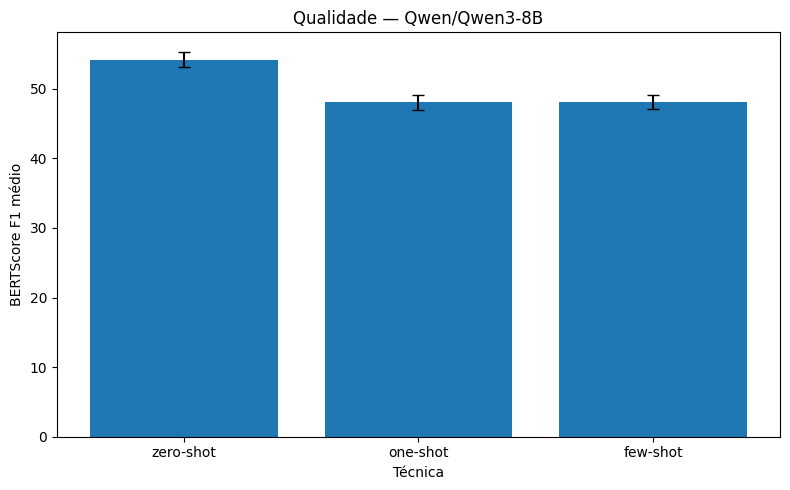

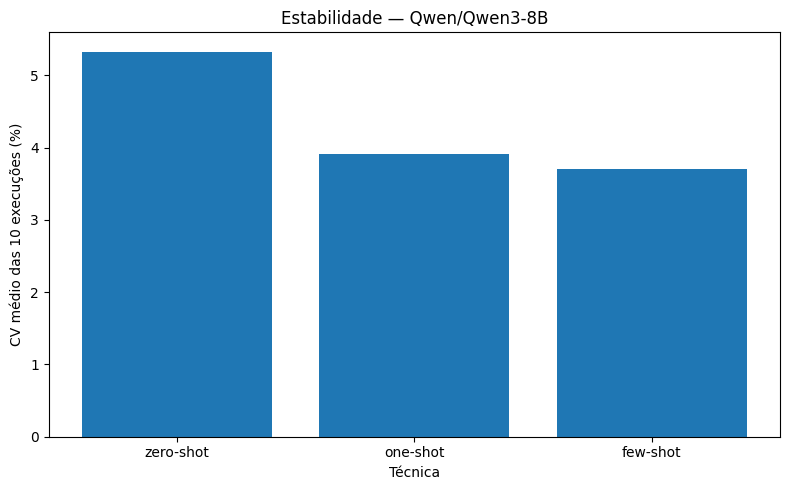

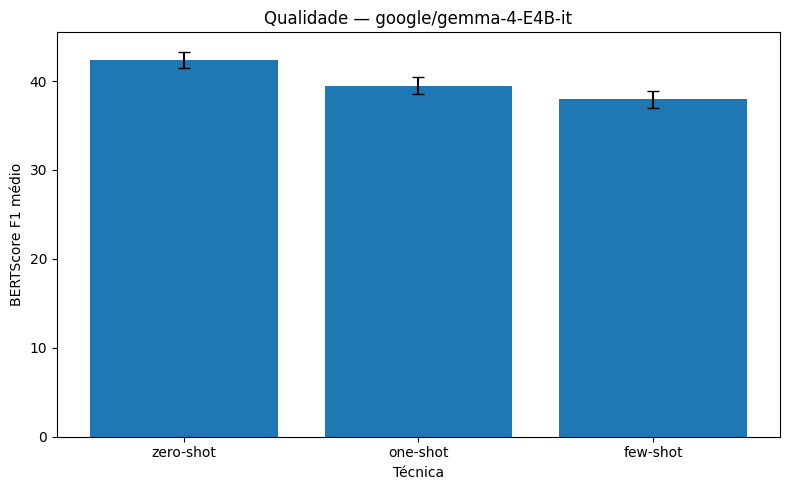

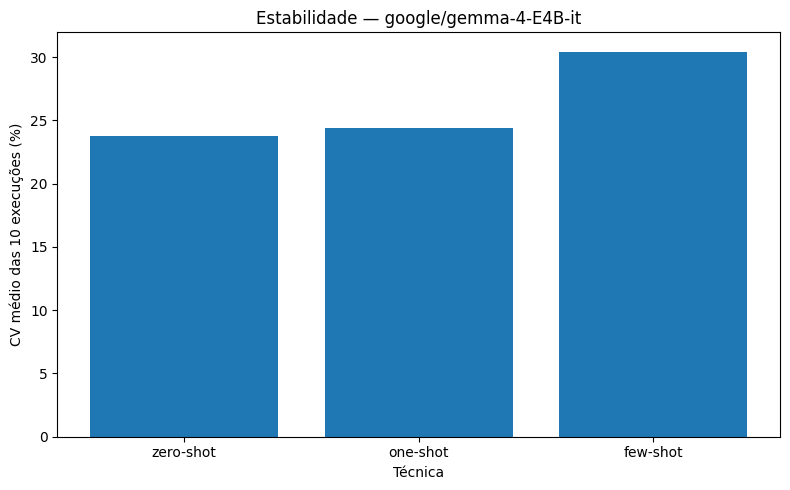

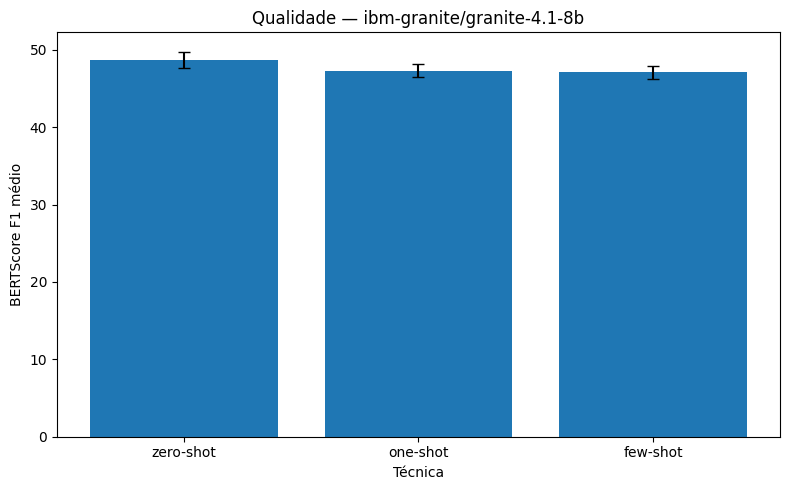

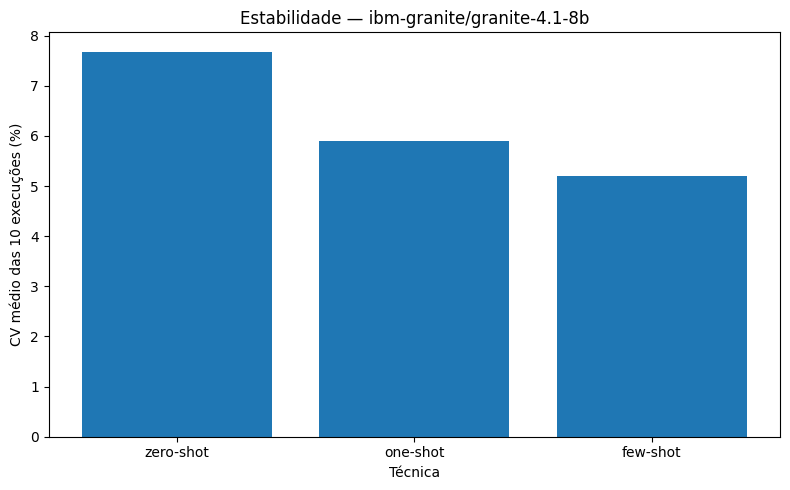

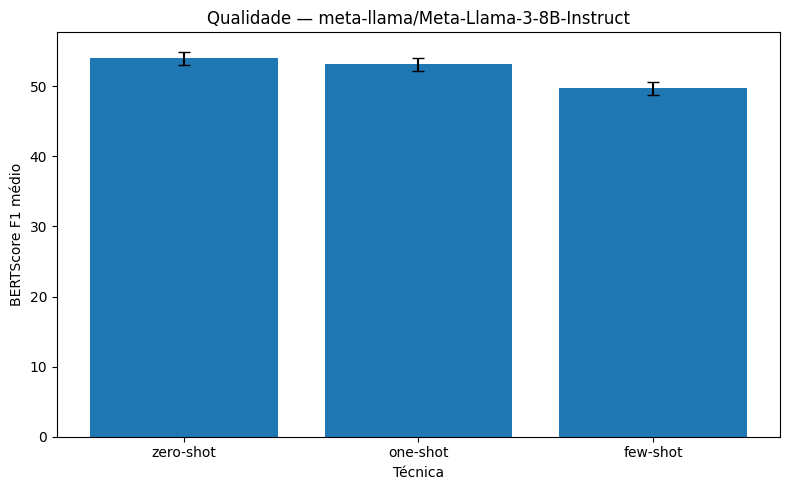

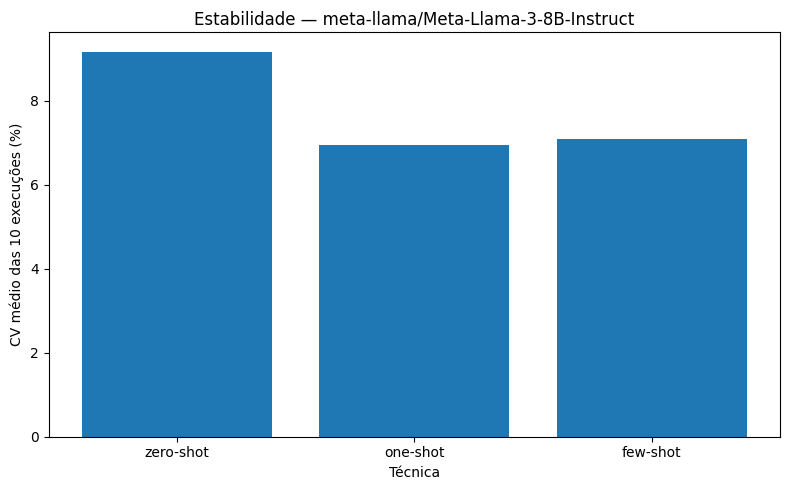

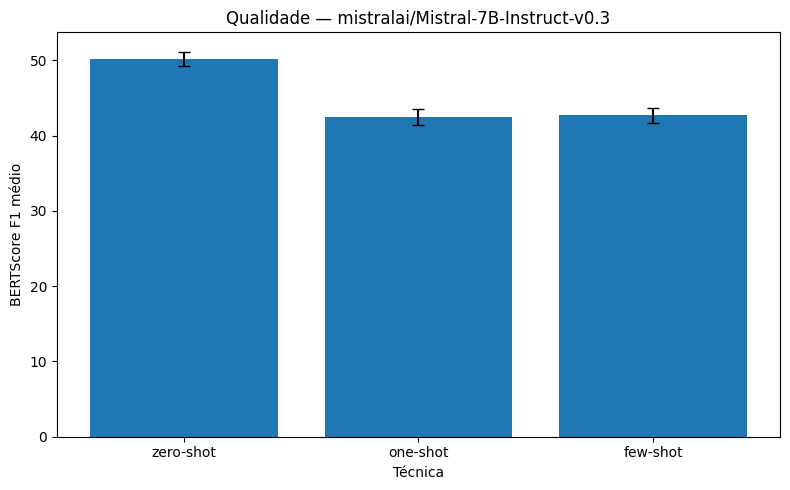

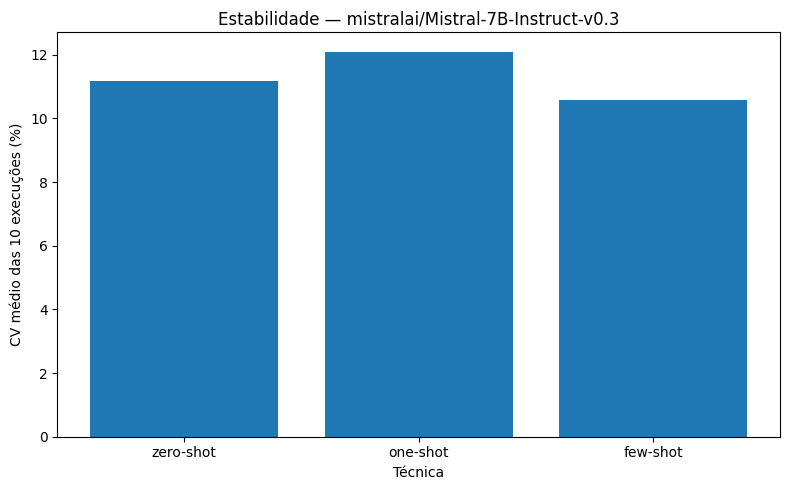

In [ ]:
for m in modelos:
    d=df_descritiva[df_descritiva["model"]==m].set_index("technique").reindex(TECNICAS_ESPERADAS).reset_index()
    plt.figure(figsize=(8,5))
    plt.bar(d["technique"],d["media_bertscore"],yerr=1.96*d["sem"],capsize=4)
    plt.ylabel("BERTScore F1 médio"); plt.xlabel("Técnica"); plt.title(f"Qualidade — {m}")
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(8,5))
    plt.bar(d["technique"],d["media_cv_execucoes"])
    plt.ylabel("CV médio das 10 execuções (%)"); plt.xlabel("Técnica"); plt.title(f"Estabilidade — {m}")
    plt.tight_layout(); plt.show()

## 14. Gerar resumo final em TXT

In [ ]:
lin=[]
def add(x=""): lin.append(str(x))

add("="*95)
add("RESUMO FINAL — BERTSCORE F1: TÉCNICAS E MODELOS")
add("="*95); add()
add("1. DESENHO")
add("-"*95)
add(f"Modelos: {len(modelos)}")
for m in modelos: add(f"  - {m}")
add(f"Técnicas: {', '.join(TECNICAS_ESPERADAS)}")
add(f"Casos por condição: {TOTAL_CASOS_ESPERADO}")
add(f"Execuções por caso: {TOTAL_EXECUCOES_ESPERADO}")
add(f"Arquivos BERTScore: {len(df_inventario)}")
add(f"Registros brutos: {len(df_bruto):,}")
add(f"Observações agregadas: {len(df_agregado):,}")
add(f"Escala BERTScore: {ESCALA_BERT}"); add()

add("2. MELHOR TÉCNICA POR MODELO")
add("-"*95)
for _,r in df_melhores_tecnicas.sort_values("modelo").iterrows():
    add(f"{r['modelo']}")
    add(f"  Melhor técnica observada: {r['melhor_tecnica_observada']}")
    add(f"  BERTScore médio: {r['media_bertscore']:.6f}")
    add(f"  CV médio: {r['media_cv_percent']:.4f}%")
    add(f"  Técnica mais estável: {r['tecnica_mais_estavel']}")
    add(f"  Status: {r['status']}")
    add(f"  Post-hoc: {r['detalhes_posthoc']}")
    add()

add("3. FRIEDMAN POR MODELO")
add("-"*95)
for _,r in df_friedman_modelo.iterrows():
    add(f"{r['modelo']}: chi2={r['friedman_chi2']:.6f}; p={r['p_value']:.6g}; Kendall W={r['kendall_W']:.6f}; {'significativo' if r['significativo'] else 'não significativo'}")
add()

add("4. TÉCNICA GLOBAL")
add("-"*95)
add(f"Maior média global: {TECNICA_GLOBAL_MELHOR}")
add(f"Friedman global: chi2={frg.statistic:.6f}; p={frg.pvalue:.6g}; Kendall W={kendall_global:.6f}")
for _,r in df_posthoc_global.iterrows():
    add(f"{r['tecnica_a']} vs {r['tecnica_b']}: Δ={r['diferenca_media_a_menos_b']:.6f}; IC95%=[{r['ic95_diff_inf']:.6f},{r['ic95_diff_sup']:.6f}]; p-Holm={r['p_holm']:.6g}; {r['interpretacao']}")
add()

add("5. MODELO LINEAR MISTO — MODELO × TÉCNICA")
add("-"*95)
if LMM_OK:
    for _,r in df_lmm_testes.iterrows():
        add(f"{r['efeito']}: LR={r['LR']:.6f}; df={int(r['df'])}; p={r['p_value']:.6g}; {'significativo' if r['significativo'] else 'não significativo'}")
    inter=bool(df_lmm_testes.loc[df_lmm_testes["efeito"]=="modelo × técnica","significativo"].iloc[0])
    if inter: add("Interpretação: interação significativa; a melhor técnica depende do modelo. Priorize as conclusões por modelo.")
    else: add("Interpretação: interação não significativa; a técnica global é um resumo mais plausível entre modelos.")
else:
    add(f"LMM não disponível/convergente: {LMM_ERRO}")
add()

add("6. COMPARAÇÃO ENTRE MODELOS — MELHOR CONFIGURAÇÃO DE CADA UM")
add("-"*95)
add(f"Friedman: chi2={frb.statistic:.6f}; p={frb.pvalue:.6g}; Kendall W={kendall_best:.6f}")
for _,r in df_ranking_modelos_best.iterrows():
    add(f"{int(r['posicao'])}º {r['model']} ({r['selected_technique']}): BERTScore médio={r['media_bertscore']:.6f}")
add("Post-hoc:")
for _,r in df_posthoc_modelos_best.iterrows():
    add(f"{r['modelo_a']} vs {r['modelo_b']}: Δ={r['diferenca_media_a_menos_b']:.6f}; IC95%=[{r['ic95_diff_inf']:.6f},{r['ic95_diff_sup']:.6f}]; p-Holm={r['p_holm']:.6g}; {r['interpretacao']}")
add()

add("7. COMPARAÇÃO ENTRE MODELOS — MESMA TÉCNICA GLOBAL")
add("-"*95)
add(f"Técnica: {TECNICA_GLOBAL_MELHOR}")
add(f"Friedman: chi2={frm.statistic:.6f}; p={frm.pvalue:.6g}; Kendall W={kendall_modelos_global:.6f}")
for _,r in df_ranking_modelos_global.iterrows():
    add(f"{int(r['posicao'])}º {r['model']}: BERTScore médio={r['media_bertscore']:.6f}")
add("Post-hoc:")
for _,r in df_posthoc_modelos_global.iterrows():
    add(f"{r['modelo_a']} vs {r['modelo_b']}: Δ={r['diferenca_media_a_menos_b']:.6f}; IC95%=[{r['ic95_diff_inf']:.6f},{r['ic95_diff_sup']:.6f}]; p-Holm={r['p_holm']:.6g}; {r['interpretacao']}")
add()

add("8. CONCLUSÃO AUTOMÁTICA")
add("-"*95)
topbest=df_ranking_modelos_best.iloc[0]; topglobal=df_ranking_modelos_global.iloc[0]
add(f"Técnica global de maior BERTScore médio: {TECNICA_GLOBAL_MELHOR}.")
add(f"Melhor configuração observada: {topbest['model']} + {topbest['selected_technique']} (média={topbest['media_bertscore']:.6f}).")
add(f"Melhor modelo sob a técnica global {TECNICA_GLOBAL_MELHOR}: {topglobal['model']} (média={topglobal['media_bertscore']:.6f}).")
add("A qualidade é definida pelo BERTScore F1 médio; estabilidade é reportada separadamente pelo CV das 10 execuções.")
add("As execuções foram agregadas antes dos testes inferenciais para evitar pseudorreplicação.")

texto="\n".join(lin)
CAMINHO_RESUMO=PASTA_SAIDA/"resumo_final_bertscore.txt"
CAMINHO_RESUMO.write_text(texto,encoding="utf-8")
print(texto)
print("\nResumo salvo em:",CAMINHO_RESUMO.resolve())

RESUMO FINAL — BERTSCORE F1: TÉCNICAS E MODELOS

1. DESENHO
-----------------------------------------------------------------------------------------------
Modelos: 5
  - Qwen/Qwen3-8B
  - google/gemma-4-E4B-it
  - ibm-granite/granite-4.1-8b
  - meta-llama/Meta-Llama-3-8B-Instruct
  - mistralai/Mistral-7B-Instruct-v0.3
Técnicas: zero-shot, one-shot, few-shot
Casos por condição: 259
Execuções por caso: 10
Arquivos BERTScore: 15
Registros brutos: 38,850
Observações agregadas: 3,885
Escala BERTScore: 0–100 (aproximada)

2. MELHOR TÉCNICA POR MODELO
-----------------------------------------------------------------------------------------------
Qwen/Qwen3-8B
  Melhor técnica observada: zero-shot
  BERTScore médio: 54.211268
  CV médio: 5.3283%
  Técnica mais estável: few-shot
  Status: vencedora estatisticamente suportada
  Post-hoc: zero-shot vs one-shot: Δ=6.153402; p-Holm=6.61974e-29; superior | zero-shot vs few-shot: Δ=6.127898; p-Holm=2.34773e-28; superior

google/gemma-4-E4B-it
  Melh

## 15. Exportar tabelas de auditoria

In [ ]:
df_inventario.to_csv(PASTA_SAIDA/"inventario_arquivos_bertscore.csv",index=False,encoding="utf-8-sig")
df_bruto.to_csv(PASTA_SAIDA/"bertscore_execucoes_consolidadas.csv",index=False,encoding="utf-8-sig")
df_agregado.to_csv(PASTA_SAIDA/"bertscore_agregado_10_execucoes.csv",index=False,encoding="utf-8-sig")
df_descritiva.to_csv(PASTA_SAIDA/"estatistica_descritiva_modelo_tecnica.csv",index=False,encoding="utf-8-sig")
df_normalidade_diferencas.to_csv(PASTA_SAIDA/"normalidade_diferencas_tecnicas.csv",index=False,encoding="utf-8-sig")
df_friedman_modelo.to_csv(PASTA_SAIDA/"friedman_tecnicas_por_modelo.csv",index=False,encoding="utf-8-sig")
df_posthoc_tecnicas.to_csv(PASTA_SAIDA/"posthoc_tecnicas_por_modelo.csv",index=False,encoding="utf-8-sig")
df_melhores_tecnicas.to_csv(PASTA_SAIDA/"melhor_tecnica_por_modelo.csv",index=False,encoding="utf-8-sig")
df_posthoc_global.to_csv(PASTA_SAIDA/"posthoc_tecnicas_global.csv",index=False,encoding="utf-8-sig")
medias_tecnica_global.to_csv(PASTA_SAIDA/"ranking_tecnicas_global.csv",index=False,encoding="utf-8-sig")
if LMM_OK:
    df_lmm_testes.to_csv(PASTA_SAIDA/"modelo_linear_misto_testes.csv",index=False,encoding="utf-8-sig")
df_ranking_modelos_best.to_csv(PASTA_SAIDA/"ranking_modelos_melhor_configuracao.csv",index=False,encoding="utf-8-sig")
df_posthoc_modelos_best.to_csv(PASTA_SAIDA/"posthoc_modelos_melhor_configuracao.csv",index=False,encoding="utf-8-sig")
df_ranking_modelos_global.to_csv(PASTA_SAIDA/"ranking_modelos_tecnica_global.csv",index=False,encoding="utf-8-sig")
df_posthoc_modelos_global.to_csv(PASTA_SAIDA/"posthoc_modelos_tecnica_global.csv",index=False,encoding="utf-8-sig")

print("Arquivos gerados:")
for p in sorted(PASTA_SAIDA.glob("*")):
    print(" -",p.name)

Arquivos gerados:
 - bertscore_agregado_10_execucoes.csv
 - bertscore_execucoes_consolidadas.csv
 - estatistica_descritiva_modelo_tecnica.csv
 - friedman_tecnicas_por_modelo.csv
 - inventario_arquivos_bertscore.csv
 - melhor_tecnica_por_modelo.csv
 - normalidade_diferencas_tecnicas.csv
 - posthoc_modelos_melhor_configuracao.csv
 - posthoc_modelos_tecnica_global.csv
 - posthoc_tecnicas_global.csv
 - posthoc_tecnicas_por_modelo.csv
 - ranking_modelos_melhor_configuracao.csv
 - ranking_modelos_tecnica_global.csv
 - ranking_tecnicas_global.csv
 - resumo_final_bertscore.txt


# Como interpretar a saída

A melhor técnica de cada modelo é escolhida pela maior média de BERTScore F1, mas o notebook informa se essa liderança é estatisticamente sustentada pelos post-hoc com Holm.

- `vencedora estatisticamente suportada`: maior média e significativamente superior às outras duas técnicas;
- `maior média observada; superioridade sobre todas não demonstrada`: lidera descritivamente, mas pelo menos uma comparação não demonstrou superioridade.

Se a interação `modelo × técnica` do modelo linear misto for significativa, a melhor técnica depende do modelo. Nesse cenário, a conclusão por modelo é mais importante do que uma única técnica global.

Para a comparação entre modelos, a análise sob a **mesma técnica global** é mais conservadora do que comparar cada modelo já usando a sua própria técnica escolhida.